# 03 - Exploratory Data Analysis (EDA)

## Objective
This notebook explores the telco churn dataset to identify important patterns, distributions, and early business insights related to customer churn.

## Goals
- examine the distribution of the target variable
- inspect key categorical and numeric variables in relation to churn
- identify patterns that may inform preprocessing and modeling decisions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
eda_df = df.copy()

none_like_cols = ["Offer", "Internet Type", "Churn Category", "Churn Reason"]
for col in none_like_cols:
    if col in eda_df.columns:
        eda_df[col] = eda_df[col].replace("None", pd.NA)

## Churn Label Distribution

In [5]:
eda_df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
eda_df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
churn_palette = {
    "No": "#4C78A8",
    "Yes": "#E07A5F"
}

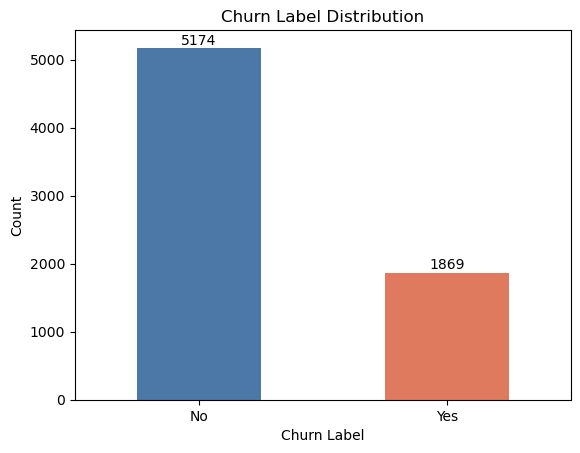

In [8]:
churn_counts = eda_df["Churn Label"].value_counts()

ax = churn_counts.plot(
    kind="bar",
    color=[churn_palette[label] for label in churn_counts.index]
)

plt.title("Churn Label Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)

for i, value in enumerate(churn_counts.values):
    ax.text(i, value + 50, str(value), ha="center")

plt.show()

This distribution shows the balance between churned and non-churned customers in the dataset.

The target appears imbalanced, which may later influence metric selection and model evaluation.

## Contract Type vs Churn

In [9]:
contract_churn = pd.crosstab(eda_df["Contract"], eda_df["Churn Label"], normalize="index")
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-Month,0.541551,0.458449
One Year,0.892903,0.107097
Two Year,0.974509,0.025491


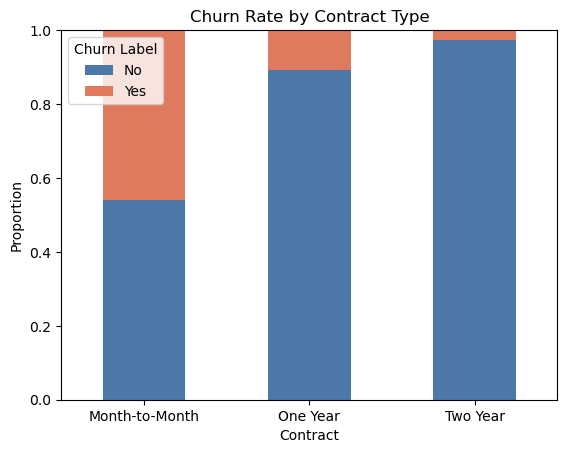

In [10]:
ax = contract_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in contract_churn.columns]
)


plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

Churn varies strongly across contract types.

Customers on month-to-month contracts show the highest churn share, while customers on longer contracts—especially two-year contracts—show much lower churn rates.

This suggests that `Contract` is likely to be an important predictive feature in the modeling stage.

### Monthly Charges vs. Churn

C:\Users\mirza\AppData\Local\Temp\ipykernel_23956\1877277203.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


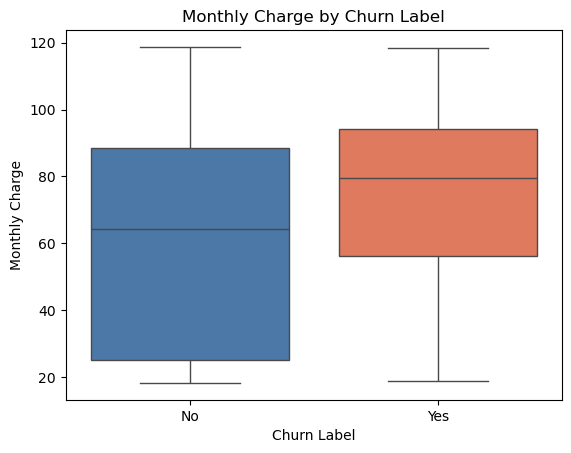

In [11]:
sns.boxplot(
    x="Churn Label",
    y="Monthly Charge",
    data=eda_df,
    order=["No", "Yes"],
    palette=churn_palette,
    saturation=1
)

plt.title("Monthly Charge by Churn Label")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charge")
plt.show()

This boxplot compares the distribution of monthly charges for churned and non-churned customers.

Key Observations:
- **Higher Median Cost:** Customers who churn (Yes) have a noticeably higher median monthly charge compared to those who stay (No).
- **Price Sensitivity:** The concentration of churned customers in the higher price range suggests that high costs may be a significant driver of customer loss.
- **Retention in Lower Brackets:** Non-churned customers show a wider distribution with a lower median, indicating that lower-priced plans might contribute to better retention.

This insight suggests that pricing strategies or high-value plan satisfaction should be further investigated.


## Tenure in Months vs Churn

C:\Users\mirza\AppData\Local\Temp\ipykernel_23956\213969297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


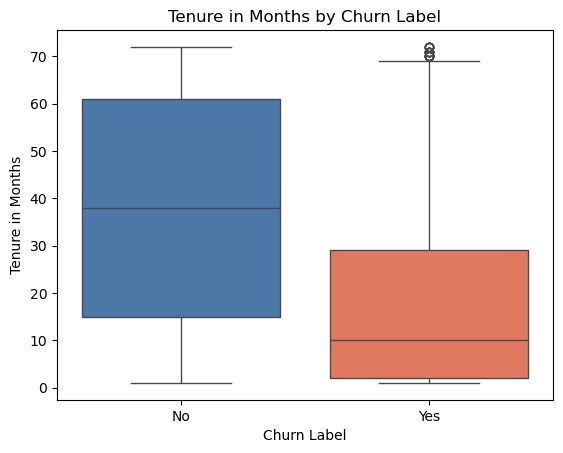

In [12]:
sns.boxplot(
    x="Churn Label",
    y="Tenure in Months",
    data=eda_df,
    order=["No", "Yes"],
    palette=churn_palette,
    saturation=1
)

plt.title("Tenure in Months by Churn Label")
plt.xlabel("Churn Label")
plt.ylabel("Tenure in Months")
plt.show()

### Detailed Interpretation:
1. **The Loyalty Gap:** The median tenure for churned customers is significantly lower (~10-15 months) compared to non-churned customers (~38 months). This indicates a high early churn rate, suggesting that the first year is the most critical period for customer retention.
2. **Predictive Power:** Since the distributions of the two classes are visually distinct, `Tenure in Months` will likely be one of the top features for our machine learning model.
3. **Strategic Recommendation:** Marketing efforts should focus on the "Early Tenure" segment (0-12 months) with engagement programs to decrease churn probability before they reach the 2-year mark.

## Total Charges vs Churn

C:\Users\mirza\AppData\Local\Temp\ipykernel_23956\3824985300.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


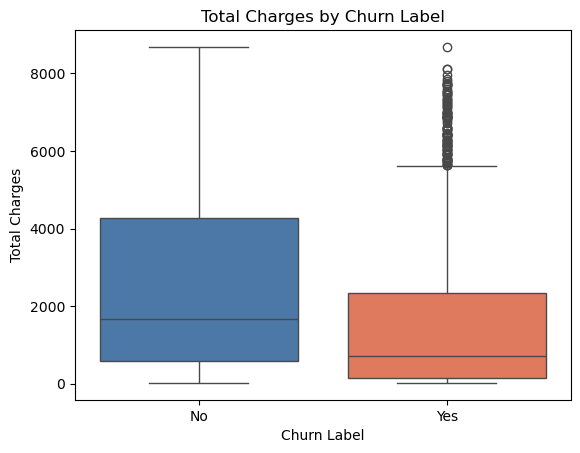

In [13]:
sns.boxplot(
    x="Churn Label",
    y="Total Charges",
    data=eda_df,
    order=["No", "Yes"],
    palette=churn_palette,
    saturation=1
)

plt.title("Total Charges by Churn Label")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")
plt.show()

### Interpretation

Customers who churned tend to have lower total charges than those who did not churn.

This likely reflects the earlier tenure pattern: customers with shorter tenure have had less time to accumulate total charges.

This suggests that `Total Charges` may be informative, but it should be interpreted together with `Tenure in Months`.

## Monthly Charge vs Tenure by Churn Label

A raw scatterplot of `Monthly Charge` versus `Tenure in Months` produced substantial overlap between churn classes and was difficult to interpret clearly.

To make the pattern more readable, tenure was grouped into broader ranges and churn behavior was examined at the group level instead.

In [14]:
eda_df["Tenure Group"] = pd.cut(
    eda_df["Tenure in Months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

In [15]:
tenure_group_churn = pd.crosstab(
    eda_df["Tenure Group"],
    eda_df["Churn Label"],
    normalize="index"
)

tenure_group_churn

Churn Label,No,Yes
Tenure Group,,
0-12,0.525618,0.474382
13-24,0.712891,0.287109
25-48,0.796110,0.203890
49-72,0.904868,0.095132


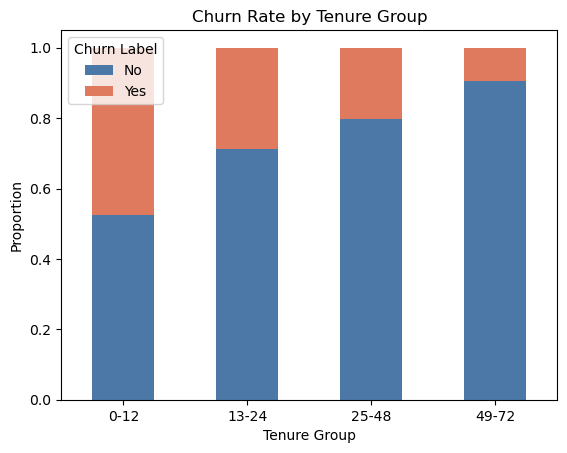

In [16]:
tenure_group_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in tenure_group_churn.columns]
)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.xlabel("Tenure Group")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.show()

### Interpretation

Grouping tenure into broader ranges makes the churn pattern easier to read than a raw scatterplot.

The distribution suggests that shorter-tenure customers are more likely to churn, while longer-tenure customers are more likely to remain.

In [17]:
eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()

C:\Users\mirza\AppData\Local\Temp\ipykernel_23956\2240341911.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()


Churn Label,No,Yes
Tenure Group,,
0-12,45.400,73.850
13-24,55.325,84.525
25-48,64.200,89.100
49-72,80.325,99.900


C:\Users\mirza\AppData\Local\Temp\ipykernel_23956\4105234654.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_by_tenure = eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()


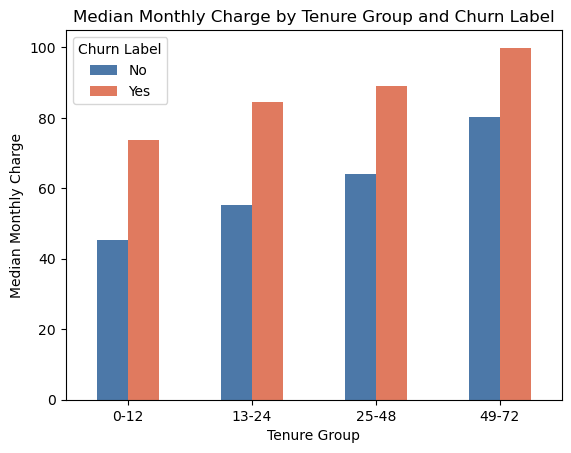

In [18]:
monthly_by_tenure = eda_df.groupby(["Tenure Group", "Churn Label"])["Monthly Charge"].median().unstack()

monthly_by_tenure.plot(
    kind="bar",
    color=[churn_palette[col] for col in monthly_by_tenure.columns]
)

plt.title("Median Monthly Charge by Tenure Group and Churn Label")
plt.ylabel("Median Monthly Charge")
plt.xlabel("Tenure Group")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.show()

### Interpretation

This grouped view shows that churn is especially concentrated among customers in the first 12 months.

Within this shorter-tenure group, monthly charges also appear relatively high, which may indicate that price sensitivity is more pronounced early in the customer lifecycle.

At this stage, this is treated as an observed pattern rather than a causal conclusion.

## Interim EDA Summary

The initial EDA suggests that churn is not evenly distributed across customer groups.

Early patterns indicate that:
- contract type is strongly associated with churn
- customers who churned tend to have higher monthly charges
- customers who churned also tend to have shorter tenure
- lower total charges among churned customers likely reflect shorter customer lifetimes

These observations may later inform preprocessing and feature evaluation.

## Internet Type vs Churn

In [19]:
internet_churn = pd.crosstab(
    eda_df["Internet Type"],
    eda_df["Churn Label"],
    normalize="index"
)

internet_churn

Churn Label,No,Yes
Internet Type,,
Cable,0.743373,0.256627
DSL,0.814165,0.185835
Fiber Optic,0.592751,0.407249


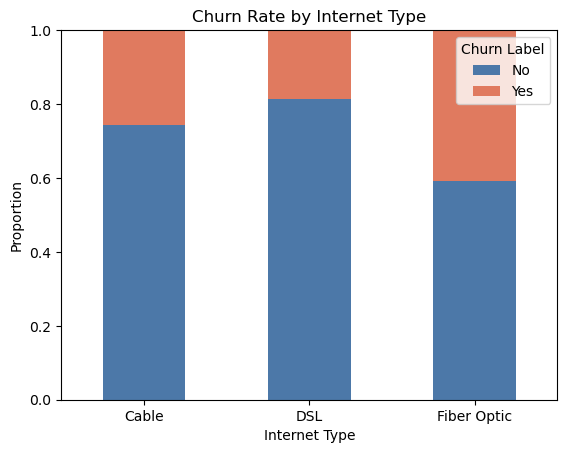

In [20]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in internet_churn.columns]
)

plt.title("Churn Rate by Internet Type")
plt.ylabel("Proportion")
plt.xlabel("Internet Type")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

**Service Impact**: Churn rates differ meaningfully across internet service types, indicating that the technology used is a strong predictor of customer retention.

**The Fiber Optic Paradox**: Customers with Fiber Optic service show the highest churn share, while DSL customers are the most loyal. This is a critical finding, as Fiber is a premium service; its high churn may be linked to higher costs or intense market competition in that segment.

**Modeling Value**: This suggests that Internet Type is a high-value feature that will provide a strong signal for the machine learning model. 


## Payment Method vs Churn

In [21]:
payment_churn = pd.crosstab(
    eda_df["Payment Method"],
    eda_df["Churn Label"],
    normalize="index"
)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,0.660015,0.339985
Credit Card,0.855220,0.144780
Mailed Check,0.631169,0.368831


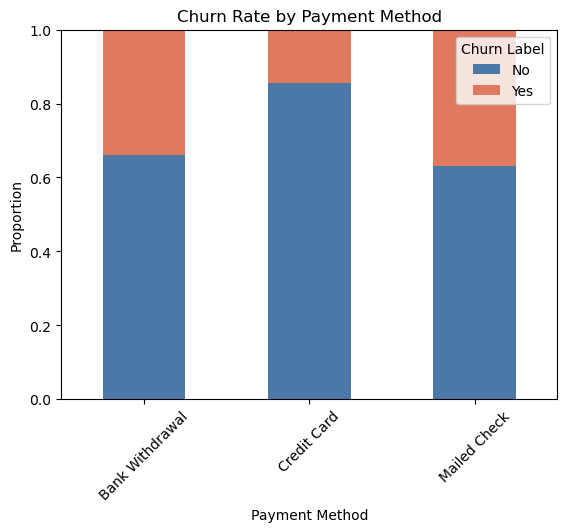

In [22]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in payment_churn.columns]
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Proportion")
plt.xlabel("Payment Method")
plt.xticks(rotation=45)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

**Payment Method Influence**: Churn rates vary significantly depending on how customers pay.

**Highest Risk**: Customers using Bank Withdrawal and Mailed Check exhibit the highest churn rates (approx. 34% and 37% respectively).

**Lowest Risk**: Customers paying via Credit Card are the most loyal, with a significantly lower churn rate of only 14.5%.

**Strategic Insight**: The high churn in "Mailed Check" and "Bank Withdrawal" might be due to transaction failures or a lack of automatic renewal convenience compared to Credit Cards.

## Gender vs Churn

In [23]:
gender_churn = pd.crosstab(
    eda_df["Gender"],
    eda_df["Churn Label"],
    normalize="index"
)

gender_churn

Churn Label,No,Yes
Gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


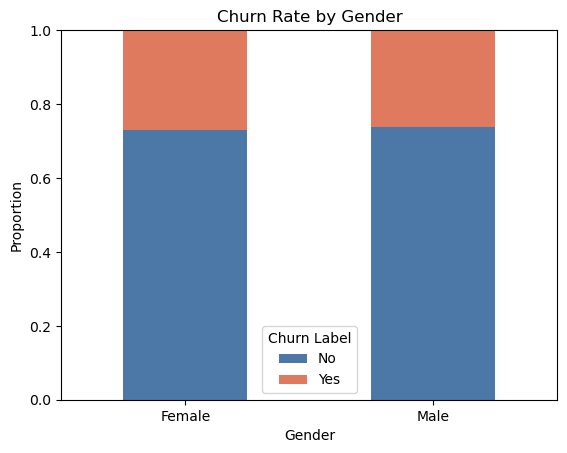

In [24]:
gender_churn.plot(
    kind="bar",
    stacked=True,
    color=[churn_palette[col] for col in gender_churn.columns]
)

plt.title("Churn Rate by Gender")
plt.ylabel("Proportion")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.ylim(0, 1)
plt.show()

### Interpretation

**Neutral Impact**: Churn rates are almost identical across genders (~26.9% for Females vs. ~26.1% for Males).

**Non-Discriminatory Factor**: This suggests that gender is not a significant driver of churn in this dataset. Customers are leaving the service regardless of their gender.

**Modeling Implication**: While we may still include Gender in the model, it is likely to have very low predictive power compared to features like Contract or Tenure.

## Categorical EDA Summary

The second EDA block suggests that churn differs meaningfully across some categorical features, but not all.

Key observations:
- `Internet Type` shows a strong difference, with Fiber Optic customers exhibiting the highest churn share
- `Payment Method` also shows a clear pattern, with Credit Card customers having the lowest churn share
- `Gender` shows little visible difference in churn rates

These results suggest that some categorical variables may carry stronger predictive signal than others.